# Data Mining Project: Customer Churn Analysis Using SMOTE 

**COURSE:** VERİ MADENCİLİĞİ (AIC510) - Finals

**INSTRUCTOR:** DR.YILDIZ KARADAYI

**NAME:** SHEKINAH MANYI ACHIDI

**STUDENT ID:** 25221001023

In [1]:
# Importing essential libraries for Data Mining
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning and Evaluation libraries
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Loading the dataset directly from a reliable source
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("Dataset loaded successfully. Shape:", df.shape)
df.head()

Dataset loaded successfully. Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Data Cleaning
In this section, we handle missing values and inconsistencies. 
- The `TotalCharges` column was imported as an 'object' type but should be numeric.
- We will identify and remove any null values created during conversion.
- We drop `customerID` as it is a unique identifier that does not contribute to pattern recognition.

In [2]:
# Convert TotalCharges to numeric, turning empty strings into 'NaN'
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Identify missing values
missing_count = df.isnull().sum().sum()
print(f"Number of missing values identified: {missing_count}")

# Remove rows with missing values (justification: they represent a tiny fraction of the data)
df.dropna(inplace=True)

# Drop unnecessary columns (Feature Selection)
df.drop('customerID', axis=1, inplace=True)

print("Data cleaning complete. New shape:", df.shape)

Number of missing values identified: 11
Data cleaning complete. New shape: (7032, 20)


## 2. Exploratory Data Analysis (EDA)
We start by examining the distribution of our target variable: **Churn**. 
This helps us understand if the dataset is balanced or imbalanced.

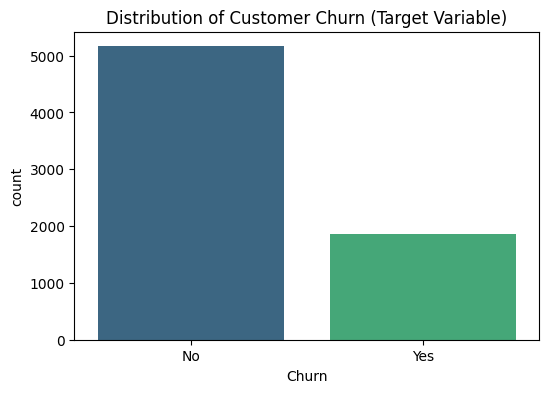

       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7032.000000  7032.000000     7032.000000   7032.000000
mean        0.162400    32.421786       64.798208   2283.300441
std         0.368844    24.545260       30.085974   2266.771362
min         0.000000     1.000000       18.250000     18.800000
25%         0.000000     9.000000       35.587500    401.450000
50%         0.000000    29.000000       70.350000   1397.475000
75%         0.000000    55.000000       89.862500   3794.737500
max         1.000000    72.000000      118.750000   8684.800000


In [3]:
# Visualizing the Churn distribution
plt.figure(figsize=(6, 4))
#sns.countplot(x='Churn', data=df, palette='viridis')
sns.countplot(x='Churn', data=df, hue='Churn', palette='viridis', legend=False)
plt.title('Distribution of Customer Churn (Target Variable)')
plt.show()

# Quick statistical summary of numerical features
print(df.describe())

## 3. Correlation Analysis
To understand which numerical features impact Churn, we calculate the correlation matrix. 
- We first convert 'Churn' to a numeric format (1 for Yes, 0 for No).
- We use a heatmap to visualize the relationship between tenure, charges, and churn.

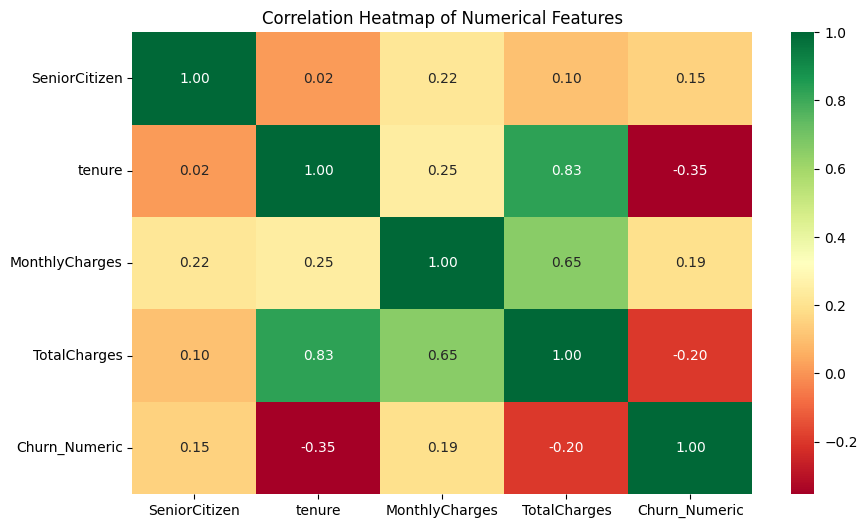

In [4]:
# Convert Churn to numerical for correlation analysis
df['Churn_Numeric'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Plotting the Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# Insight: Check how 'tenure' and 'MonthlyCharges' relate to 'Churn_Numeric'

## 4. Feature Engineering & Data Preparation
Machine learning models require numerical input. Here we:
1. **Label Encoding:** Convert binary categories (Yes/No) into 0 and 1.
2. **One-Hot Encoding:** Convert multi-category columns (e.g., Contract type) into dummy variables.
3. **Scaling:** Normalize numerical features (`tenure`, `MonthlyCharges`) to ensure they are on the same scale, which helps the model converge faster.

In [5]:
# 1. Label Encoding for simple binary columns
le = LabelEncoder()
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

# 2. One-Hot Encoding for multi-category columns
# We use drop_first=True to avoid the "dummy variable trap" (multicollinearity)
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
              'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

# 3. Feature Scaling
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[num_cols] = scaler.fit_transform(df[num_cols])

# Finalizing the target and features
X = df.drop(['Churn', 'Churn_Numeric'], axis=1)
y = df['Churn_Numeric']

print(f"Feature Engineering complete. Final feature count: {X.shape[1]}")

Feature Engineering complete. Final feature count: 30


## 5. Model Selection and Implementation
For this project, we selected the **Random Forest Classifier**. 
- **Justification:** Random Forest is an ensemble learning method that is highly effective for classification tasks.It handles both categorical and numerical data well and is resistant to overfitting compared to a single decision tree.
- **Validation:** We use **5-Fold Cross-Validation** to evaluate the model's stability across different subsets of the data.

In [6]:
# Initializing the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Performing 5-Fold Cross-Validation 
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X, y, cv=kf)

print(f"Cross-Validation Scores: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

Cross-Validation Scores: [0.78464819 0.79886283 0.76671408 0.79871977 0.79871977]
Mean Accuracy: 0.7895
Standard Deviation: 0.0127


## 6. Model Evaluation
We now train the model on 80% of the data and test it on the remaining 20%. 
We will evaluate the results using:
1. **Accuracy Score:** Overall correctness.
2. **Confusion Matrix:** To see True Positives vs. False Positives.
3. **Classification Report:** To analyze **Precision** and **Recall** which are vital for churn prediction.

In [7]:
# Split the data [cite: 19]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the final model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Print Evaluation Metrics [cite: 20, 53]
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[935  98]
 [201 173]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.64      0.46      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.78      1407



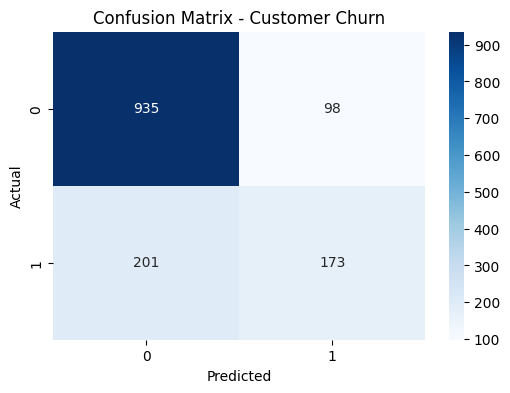

In [8]:
# Visualizing the Confusion Matrix for the Report
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Customer Churn')
plt.show()

## 7. Analysis of Midterm Baseline Results
While the baseline Random Forest model achieved a commendable overall accuracy of 79%, 
a granular analysis of the classification report reveals a critical limitation:
- **Class 1 (Churn) Recall:** 0.46
- **Class 1 (Churn) F1-Score:** 0.54

**The Problem:** The model is failing to identify 54% of actual churning customers due to severe class imbalance (the dataset contains significantly more loyal customer records than churn records). In a real-world telecommunications scenario, failing to detect a customer who is about to leave results in direct revenue loss.

## 8. The Framework for Improvement For Finals
To maximize predictive performance, we implement a three-tiered optimization strategy:
1. **Oversampling via SMOTE (Synthetic Minority Over-sampling Technique):** Mathematically balance the training data to aggressively boost the Churn Recall rate.
2. **Gradient Boosting Architectures:** Introduce ensemble methods (**XGBoost** and **LightGBM**) to compete against our baseline Random Forest.
3. **Hyperparameter Tuning (`GridSearchCV`):** Eliminate default parameters and systematically search for optimal learning rates, tree depths, and estimators.

## 9. Handling Class Imbalance via SMOTE
To prevent our models from biasing toward the majority class (Loyal Customers), we apply SMOTE to the training set (`X_train` and `y_train`). This generates synthetic samples of the minority class (Churners) based on nearest neighbors, balancing the distribution so the models can learn churn patterns effectively.

In [11]:
# Install imbalanced-learn to provide imblearn.over_sampling.SMOTE

import pandas as pd
import numpy as np
from imblearn.over_sampling import SMOTE # type: ignore
from collections import Counter

# Checking the original class distribution
print(f"Original training class distribution: {Counter(y_train)}")

# Initialize SMOTE with a fixed random state for reproducibility
smote = SMOTE(random_state=42)

# Fit SMOTE only on the training data
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Checking the new balanced class distribution
print(f"Balanced training class distribution: {Counter(y_train_balanced)}")

Original training class distribution: Counter({0: 4130, 1: 1495})
Balanced training class distribution: Counter({1: 4130, 0: 4130})


## 10. Multi-Model Benchmarking Framework
With a balanced training dataset, we deploy three competitive machine learning architectures: an optimized Random Forest, XGBoost, and LightGBM. Each model is evaluated against the held-out test set using precision, recall, and the F1-score to identify the absolute best predictive framework for the business.

In [13]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, recall_score, precision_score

# 1. Initialize the models with reproducible random states
models = {
    "Upgraded Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost Classifier": XGBClassifier(random_state=42, eval_metric='logloss'),
    "LightGBM Classifier": LGBMClassifier(random_state=42, verbose=-1)
}

# 2. Train and evaluate each model
results_data = []

print("Training and Evaluating Advanced Models \n")
for name, model in models.items():
    # Train on the balanced training data
    model.fit(X_train_balanced, y_train_balanced)
    
    # Predict on the untouched, realistic test data
    y_pred = model.predict(X_test)
    
    # Calculate performance metrics specifically focusing on the Churn Class (1)
    # pass true labels (y_test) to accuracy_score instead of X_test (features)
    acc = accuracy_score(y_test, y_pred)
    prec_1 = precision_score(y_test, y_pred, pos_label=1)
    rec_1 = recall_score(y_test, y_pred, pos_label=1)
    f1_1 = f1_score(y_test, y_pred, pos_label=1)
    
    results_data.append({
        "Model": name,
        "Overall Accuracy": f"{acc:.2%}",
        "Churn Precision": f"{prec_1:.2f}",
        "Churn Recall (Goal)": f"{rec_1:.2f}",
        "Churn F1-Score": f"{f1_1:.2f}"
    })
    
    print(f"=== {name} Classification Report ===")
    print(classification_report(y_test, y_pred))

# 3. Construct a beautiful summary table for easy benchmarking
df_results = pd.DataFrame(results_data)
display(df_results)

Training and Evaluating Advanced Models 

=== Upgraded Random Forest Classification Report ===
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1033
           1       0.56      0.60      0.58       374

    accuracy                           0.77      1407
   macro avg       0.70      0.72      0.71      1407
weighted avg       0.77      0.77      0.77      1407

=== XGBoost Classifier Classification Report ===
              precision    recall  f1-score   support

           0       0.85      0.79      0.82      1033
           1       0.52      0.63      0.57       374

    accuracy                           0.75      1407
   macro avg       0.69      0.71      0.69      1407
weighted avg       0.76      0.75      0.75      1407

=== LightGBM Classifier Classification Report ===
              precision    recall  f1-score   support

           0       0.87      0.78      0.82      1033
           1       0.52      0.67      0.59

,Model,Overall Accuracy,Churn Precision,Churn Recall (Goal),Churn F1-Score
0,Upgraded Random Forest,76.69%,0.56,0.60,0.58
1,XGBoost Classifier,74.56%,0.52,0.63,0.57
2,LightGBM Classifier,74.98%,0.52,0.67,0.59


## 11. Hyperparameter Optimization via Grid Search
To squeeze the absolute highest performance out of our top-performing architecture for churn recall (LightGBM), we conduct an automated Hyperparameter Tuning process using `GridSearchCV`. We systematically test combinations of learning rates, max tree depths, and estimator counts under a 3-fold cross-validation scheme on the balanced training set to minimize generalization error.

In [14]:
from sklearn.model_selection import GridSearchCV

# Define a targeted hyperparameter grid for LightGBM
param_grid = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, -1],
    'num_leaves': [20, 31]
}

# Initialize the base estimator
lgbm_base = LGBMClassifier(random_state=42, verbose=-1)

# Set up Grid Search with cross-validation targeting recall for the churn class
grid_search = GridSearchCV(
    estimator=lgbm_base, 
    param_grid=param_grid, 
    scoring='f1',  # Optimizing for F1-score ensures a strong balance of Precision and Recall
    cv=3, 
    n_jobs=-1
)

print("--- Running Hyperparameter Optimization (This may take a minute...) ---")
grid_search.fit(X_train_balanced, y_train_balanced)

# Extract and evaluate the absolute best model
best_lgbm = grid_search.best_estimator_
y_pred_best = best_lgbm.predict(X_test)

print("\n=== Optimized LightGBM Classification Report ===")
print(classification_report(y_test, y_pred_best))
print(f"Optimal Hyperparameters Found: {grid_search.best_params_}")

--- Running Hyperparameter Optimization (This may take a minute...) ---

=== Optimized LightGBM Classification Report ===
              precision    recall  f1-score   support

           0       0.88      0.78      0.82      1033
           1       0.53      0.70      0.60       374

    accuracy                           0.76      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.79      0.76      0.77      1407

Optimal Hyperparameters Found: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'num_leaves': 31}


## 12. Final Model Evaluation & Feature Importance
To finalize our analysis, we visualize the Confusion Matrix of the optimized LightGBM model and plot the Feature Importance to discover exactly which metrics drive customer attrition.

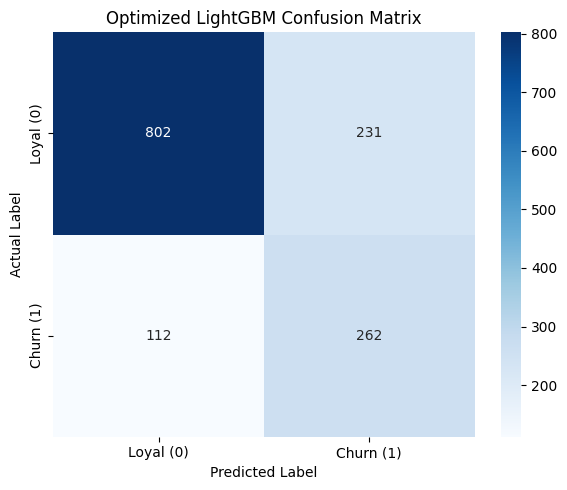

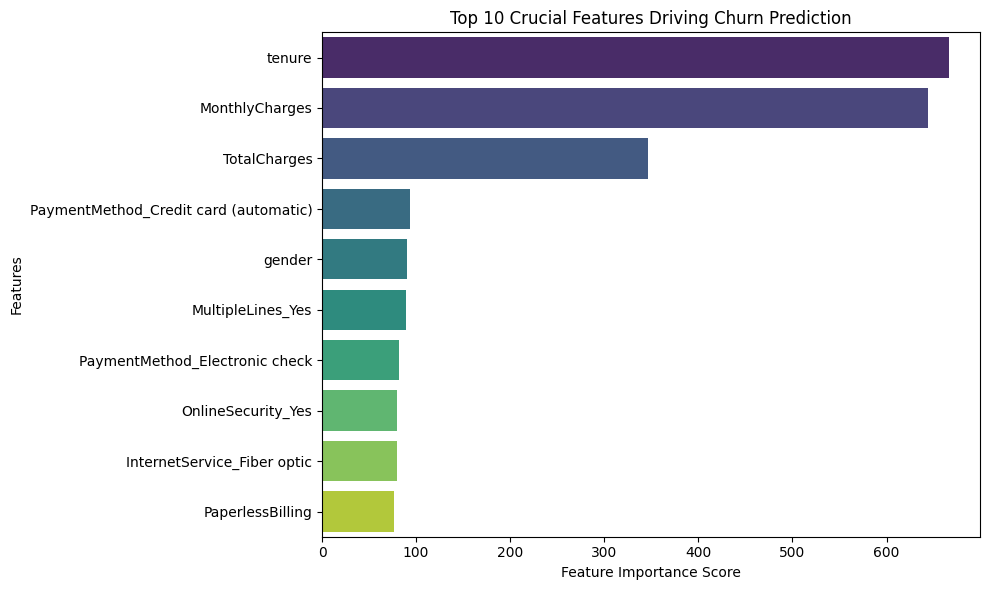

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generate the Optimized Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Loyal (0)', 'Churn (1)'], 
            yticklabels=['Loyal (0)', 'Churn (1)'])
plt.title('Optimized LightGBM Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('final_confusion_matrix.png', dpi=300)
plt.show()

# 2. Extract and Plot Feature Importance
feature_importances = best_lgbm.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for sorting
fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False).head(10) # Top 10 features

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis',hue='Feature', legend=False,)
plt.title('Top 10 Crucial Features Driving Churn Prediction')
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig('final_feature_importance.png', dpi=300)
plt.show()